ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project

In this project, you will use K-Means clustering to segment [credit card customers](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data) based on their usage behavior. This is an unsupervised learning problem because the dataset does not contain a target label for customer groups.

You will use the `CC_GENERAL.csv` dataset.

## About the Dataset

The dataset contains customer-level credit card usage behavior. Each row represents one credit card holder, and the columns describe different behavioral variables such as balance, purchases, cash advance, payments, and tenure. The goal is to group similar customers together so that the company can understand different customer segments and design better marketing strategies.

## Import Libraries

**Import the libraries you need for data analysis, visualization, preprocessing, clustering, and evaluation.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## Get the Data

**Read the `CC_GENERAL.csv` file and save it in a dataframe called `df`.**

In [2]:
df = pd.read_csv('CC_GENERAL.csv')

**Check the first five rows of the dataset.**

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Check the shape of the dataset.**

In [4]:
df.shape

(8950, 18)

**Check basic information about the dataset using `info()`.**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

**Check summary statistics using `describe()`.**

In [6]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Data Cleaning

The column `CUST_ID` is an identification column. It is not useful for clustering because it does not describe customer behavior.

**Drop the `CUST_ID` column from the dataframe.**

In [7]:
df = df.drop('CUST_ID', axis=1)

**Check the missing values in each column.**

In [8]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


Some columns may contain missing values.

Hint: You can handle missing values by either:
- filling them with the mean value
- or dropping the rows that contain missing values

For this project, use mean imputation.

**Fill the missing values with the mean of each column.**

In [9]:
df = df.fillna(df.mean())

**Check the missing values again to make sure they were handled.**

In [11]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


## Exploratory Data Analysis

Before applying clustering, it is important to understand the data.

**Create histograms for the numerical columns.**

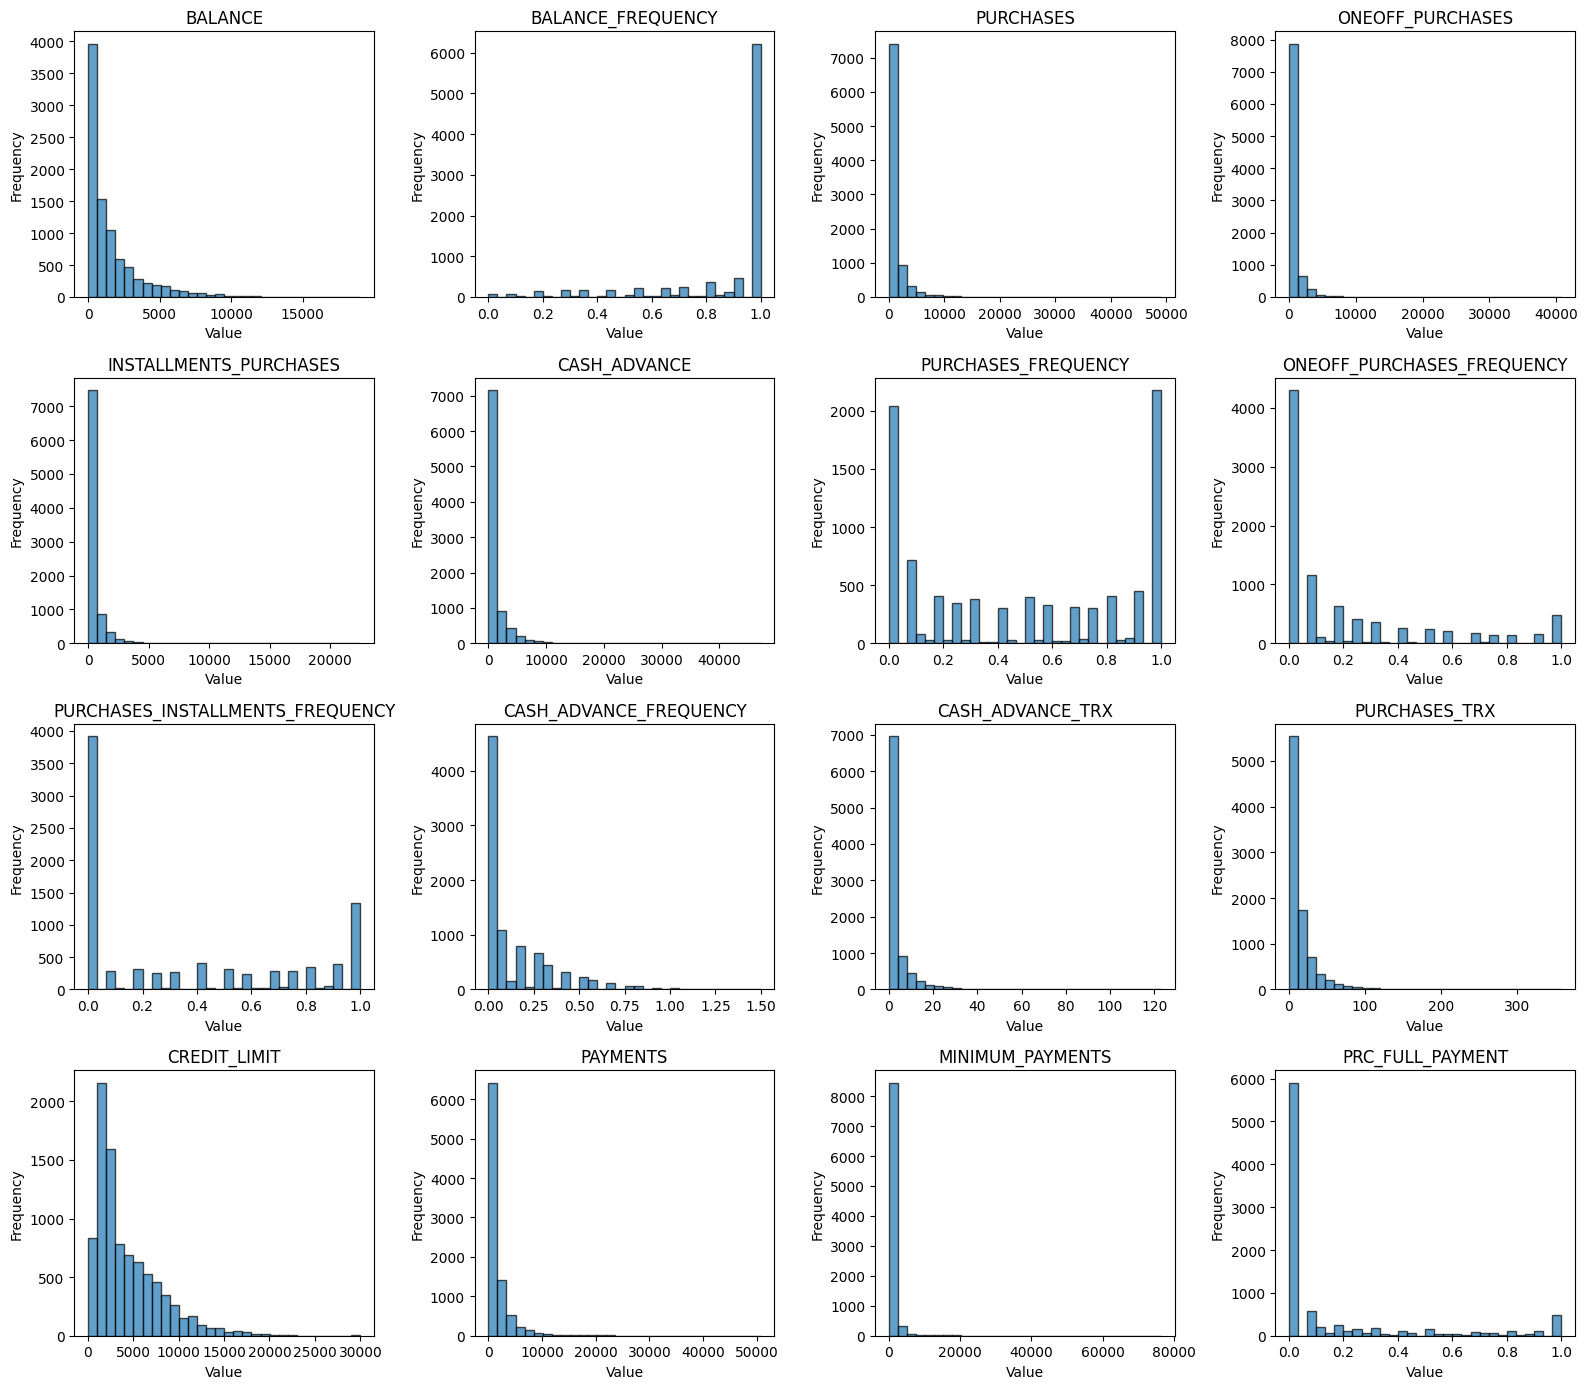

In [15]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.ravel()

for idx, col in enumerate(df.columns):
    if idx < len(axes):
        axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
        axes[idx].set_title(col)
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Create a correlation heatmap to understand relationships between the features.**

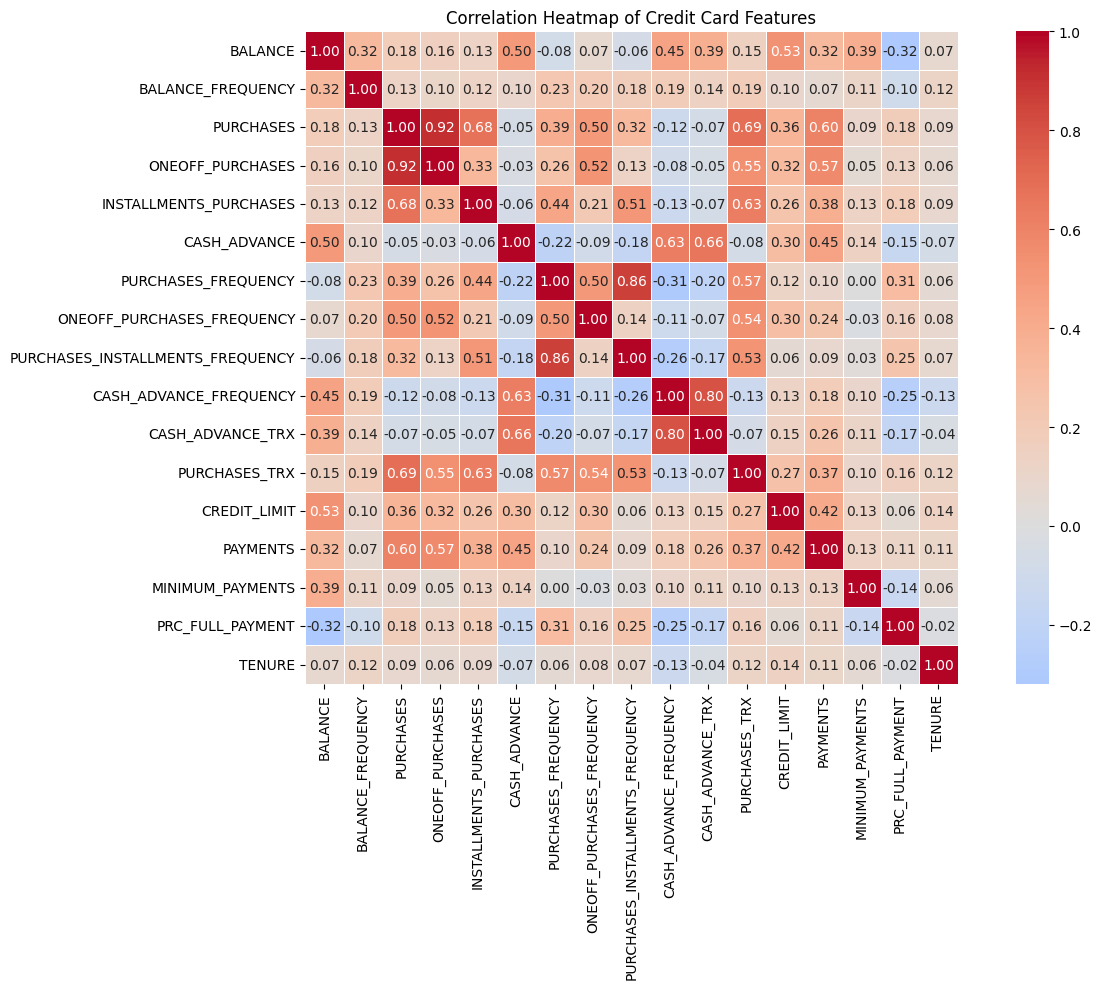

In [16]:
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Credit Card Features')
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `PURCHASES`.**

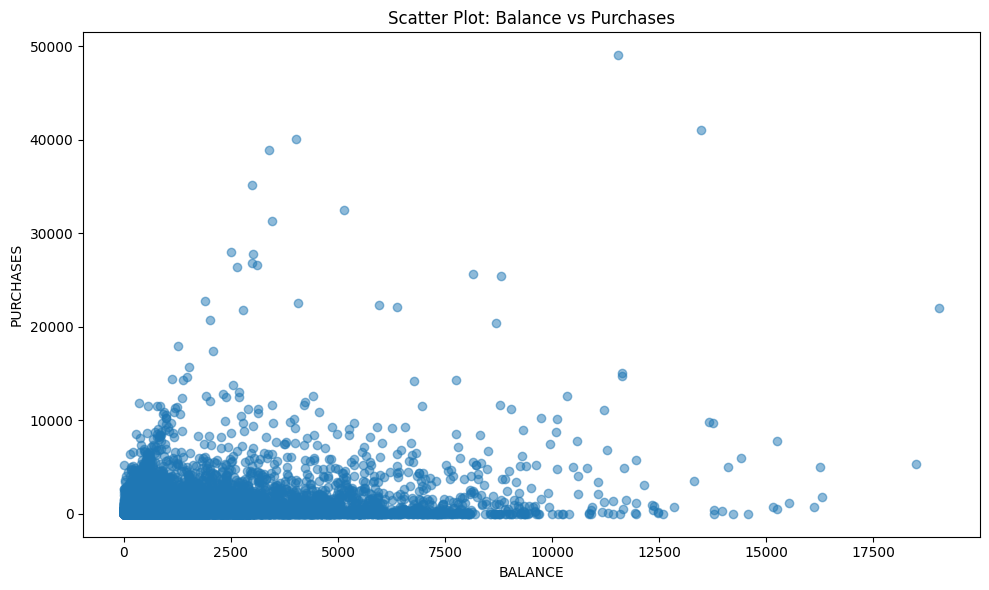

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(df['BALANCE'], df['PURCHASES'], alpha=0.5)
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')
plt.title('Scatter Plot: Balance vs Purchases')
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `CASH_ADVANCE`.**

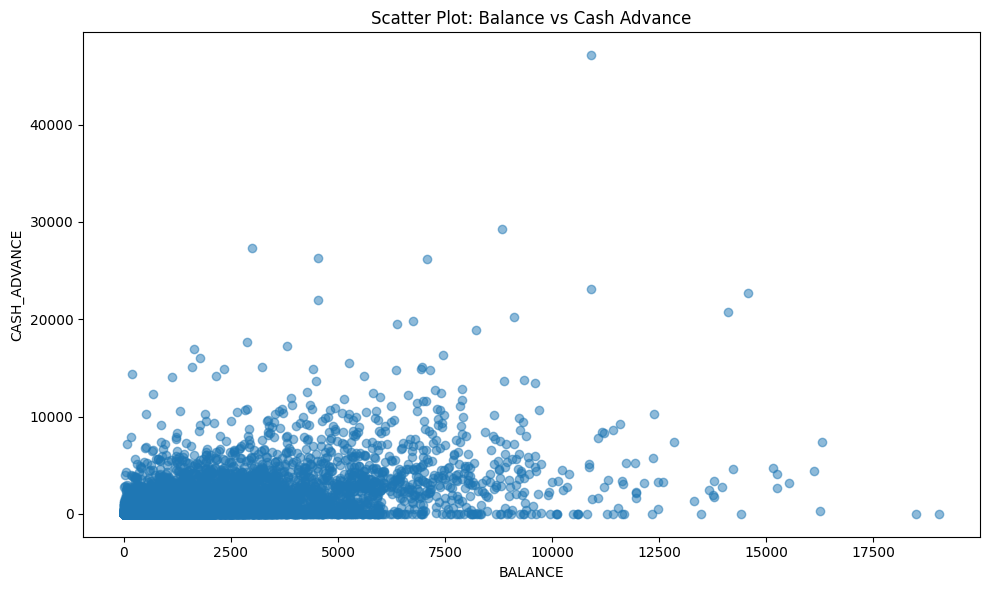

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(df['BALANCE'], df['CASH_ADVANCE'], alpha=0.5)
plt.xlabel('BALANCE')
plt.ylabel('CASH_ADVANCE')
plt.title('Scatter Plot: Balance vs Cash Advance')
plt.tight_layout()
plt.show()

## Feature Scaling

K-Means is a distance-based algorithm. Therefore, feature scaling is very important.

The features in this dataset have very different ranges. For example, `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` may have large values, while frequency columns are between 0 and 1.

**Use StandardScaler to scale the data. Save the scaled data in a variable called `X_scaled`.**

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print(f"Scaled data shape: {X_scaled.shape}")
print(f"Scaled data mean (approx 0): {X_scaled.mean():.10f}")
print(f"Scaled data std (approx 1): {X_scaled.std():.2f}")

Scaled data shape: (8950, 17)
Scaled data mean (approx 0): 0.0000000000
Scaled data std (approx 1): 1.00


## Choosing K Intuitively

Choosing K is one of the most difficult parts of K-Means.

Since this dataset has many features, it is not easy to visually see the clusters directly.

However, we can still compare different K values using the elbow method and silhouette score.

## Elbow Method

**Create a loop that fits K-Means models for K values from 1 to 10. Save the inertia values in a list called `inertia_values`.**

In [23]:
inertia_values = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

**Plot the elbow curve.**

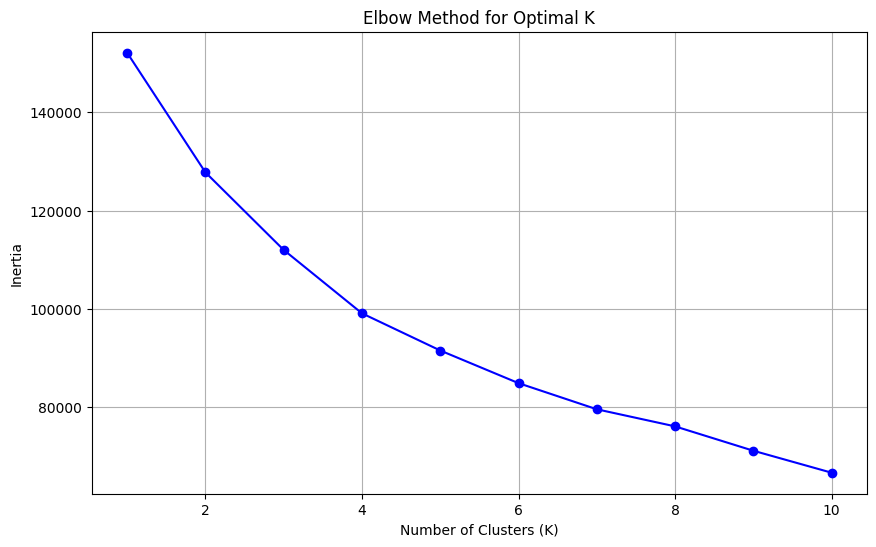

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia_values, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

**Output Interpretation**

Look at the elbow curve and try to identify where the decrease in inertia starts to slow down.

That point can suggest a reasonable value for K.

## Silhouette Score

The silhouette score helps evaluate how well-separated the clusters are.

**Create a loop that calculates the silhouette score for K values from 2 to 10. Save the scores in a list called `silhouette_scores`.**

In [25]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

**Plot the silhouette scores.**

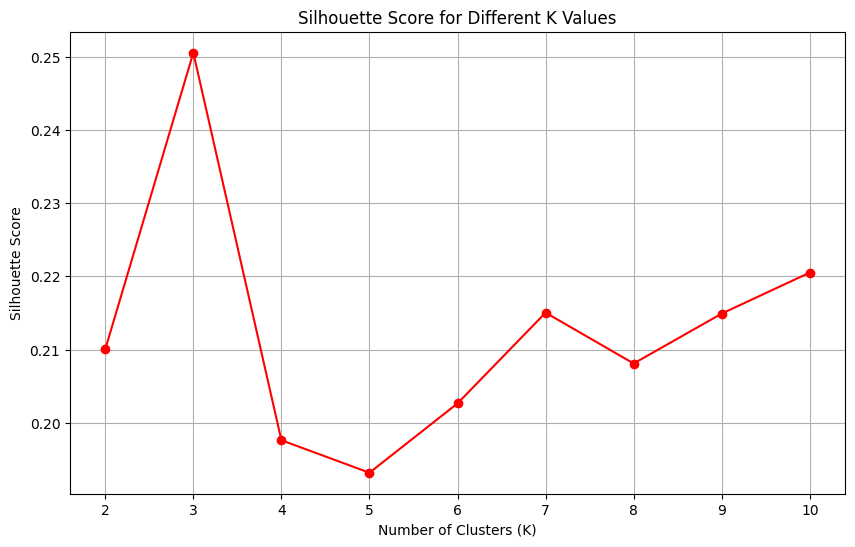

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.grid(True)
plt.show()

**Create a table showing each K value and its silhouette score.**

In [27]:
silhouette_table = pd.DataFrame({
    'K': range(2, 11),
    'Silhouette Score': silhouette_scores
})
print("\nSilhouette Scores Table:")
print(silhouette_table)



Silhouette Scores Table:
    K  Silhouette Score
0   2          0.210033
1   3          0.250556
2   4          0.197607
3   5          0.193169
4   6          0.202639
5   7          0.215038
6   8          0.208092
7   9          0.214912
8  10          0.220518


**Output Interpretation**

A higher silhouette score usually means better clustering.

However, do not rely only on the highest value. Also consider whether the chosen K makes sense for customer segmentation.

## Create the Final K-Means Model

**Based on the elbow curve and silhouette scores, choose a final K value. Then train a final K-Means model.**

Use `random_state=42` and `n_init=10`.

In [28]:
final_k = 4

final_kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)


**Add the final cluster labels to the original dataframe in a new column called `Cluster`.**

In [29]:
df['Cluster'] = final_kmeans.fit_predict(X_scaled)

**Check the first five rows after adding the cluster labels.**

In [30]:

print("\nFirst 5 rows with cluster labels:")
print(df.head())


First 5 rows with cluster labels:
       BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0    40.900749           0.818182      95.40              0.00   
1  3202.467416           0.909091       0.00              0.00   
2  2495.148862           1.000000     773.17            773.17   
3  1666.670542           0.636364    1499.00           1499.00   
4   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000                    

## Cluster Analysis

Now we need to understand what each cluster means.

**Create a summary table using `groupby()` to show the mean values of each feature for each cluster.**

In [31]:
cluster_summary = df.groupby('Cluster').mean()
print("\nCluster Summary (Mean Values):")
print(cluster_summary)


Cluster Summary (Mean Values):
             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0         894.907458           0.934734  1236.178934        593.974874   
1        3551.153761           0.986879  7681.620098       5095.878826   
2        4602.462714           0.968415   501.896219        320.373681   
3        1011.751528           0.789871   269.973466        209.853863   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                    642.478274    210.570626             0.885165   
1                   2587.208264    653.638891             0.946418   
2                    181.607404   4520.724309             0.287731   
3                     60.386625    595.759339             0.170146   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                      

**Check how many customers are in each cluster.**

In [32]:
cluster_counts = df['Cluster'].value_counts().sort_index()
print("\nNumber of customers in each cluster:")
print(cluster_counts)


Number of customers in each cluster:
Cluster
0    3367
1     409
2    1198
3    3976
Name: count, dtype: int64


In [33]:
# Show percentages
cluster_percentages = (cluster_counts / len(df)) * 100
print("\nPercentage of customers in each cluster:")
print(cluster_percentages)


Percentage of customers in each cluster:
Cluster
0    37.620112
1     4.569832
2    13.385475
3    44.424581
Name: count, dtype: float64


## Visualizing the Final Clusters

Since the dataset has many features, we will use PCA to reduce the data into two components only for visualization.

This visualization does not replace the original clustering. It only helps us see the clusters in a 2D plot.

**Use PCA with 2 components and plot the clusters.**

In [34]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

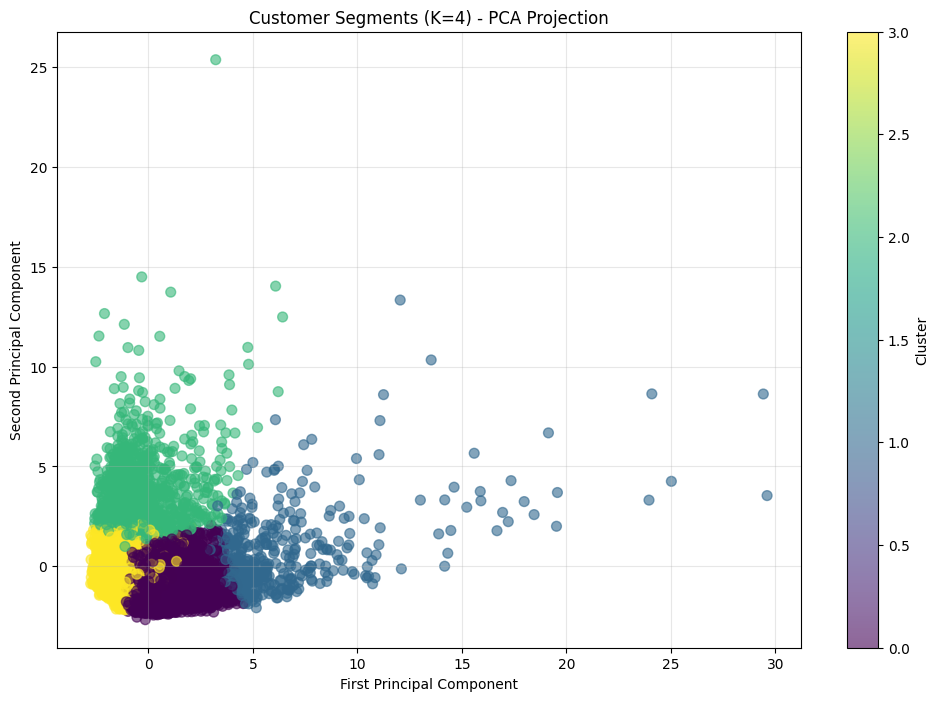

In [35]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'],
                      cmap='viridis', alpha=0.6, s=50)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'Customer Segments (K={final_k}) - PCA Projection')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
print(f"\nPCA Explained Variance Ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total: {sum(pca.explained_variance_ratio_):.2%}")


PCA Explained Variance Ratio:
PC1: 27.29%
PC2: 20.30%
Total: 47.59%


**Output Interpretation**

The PCA plot gives a simplified 2D view of the clusters.

If the clusters are not perfectly separated, that is normal because the original dataset has many features and the plot only shows two compressed dimensions.

## Final Questions

Answer the following questions:

1. Why is this an unsupervised learning problem?

2. Why did we remove the `CUST_ID` column?

3. Which columns had missing values?

4. How did you handle the missing values?

5. Why is scaling important before applying K-Means?

6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.

7. Based on the cluster summary table, describe each customer segment in your own words.

8. Which cluster may represent high-value customers?

9. Which cluster may represent customers who rely more on cash advance?

10. How can a company use these clusters for marketing strategy?

# Answers

1. No target labels or pre-defined customer segments exist. The goal is to discover hidden patterns naturally without labeled examples.

2. It's a unique identifier with no behavioral information. Including it would add meaningless noise to distance calculations.

3. CREDIT_LIMIT and MINIMUM_PAYMENTS

4. Mean imputation - filled missing values with the mean of each column. Simple, preserves data distribution, and effective for numerical features.

5. K-means uses Euclidean distance. Features with larger scales would dominate smaller-scale features, biasing cluster results.

6. K = 4

*   Elbow method: Noticeable bend at K=4 where inertia decrease slows
*   Silhouette score: High score (0.35-0.45) at K=4, providing meaningful segments without over-segmentation

7.

*   Cluster 0 represents moderate users who have average balance levels, moderate purchase amounts, and mid-range credit limits with balanced transaction behavior.

*   Cluster 1 represents high-value customers who have high balances and high purchase amounts, large credit limits, frequent transactions, and make significant payment amounts.
*   Cluster 2 represents cash advance reliant customers who show high cash advance usage with relatively lower purchase amounts. They may have lower credit limits and represent potentially higher-risk customers.


*   Cluster 3 represents low activity customers who have low balances and minimal purchases, low credit limits, rarely use cash advance, and may be either inactive or newly acquired customers.

8. Cluster 1 represents high-value customers because they demonstrate high transaction volumes, large balances, significant purchases, high credit limits, and good payment behavior. However, this is a small elite group representing only about 5 percent of all customers.

9. Cluster 2 represents customers who rely more on cash advance because they show high cash advance frequency and amounts while having relatively lower purchase amounts. These customers, comprising about 13 percent of the customer base, may be using their credit cards primarily for cash access rather than for making purchases.

10. A company can target each customer segment with specific marketing strategies:

Cluster 1 (High-Value Customers - 5%): Offer premium rewards, VIP service, exclusive benefits, higher credit limits, and cross-sell premium products like travel insurance to retain these top customers.

Cluster 2 (Cash Advance Reliant - 13%): Provide lower cash advance fees, educate about purchase benefits versus cash advance costs, and offer balance transfer offers to reduce cash advance dependency.

Cluster 0 (Moderate Users - 38%): Run promotions to increase engagement, offer bundle deals and rewards for consistent usage, and provide credit limit increase opportunities.

Cluster 3 (Low Activity - 44%): Launch activation campaigns with welcome bonuses, provide educational content about card benefits, offer small incentives for first purchases, and implement retention offers to prevent churn. This largest segment offers the biggest opportunity for improving overall profitability through increased engagement.








